# Skills Demand Analysis: Uncovering Top Skills and Tools in the AI Job Market

**Author:** Rendy Bagoes
**Date:** April 10, 2026

## 1. Introduction

Welcome to this in-depth analysis of skills and tools demanded by the AI job market. In this notebook, we'll dissect job posting data to identify which programming languages, libraries, and platforms are most sought after by employers.

### 1.1. Objectives

Our primary goals are to:
1.  **Identify Top Skills:** Determine the most frequently mentioned skills in job descriptions.
2.  **Analyze Skill Correlations:** Understand how different skills are related and which ones are often required together.
3.  **Segment by Experience:** Compare skill requirements across different experience levels (e.g., Entry, Mid, Senior).
4.  **Highlight Top Tools:** Pinpoint the most popular software and platforms in the AI/ML ecosystem.

### 1.2. Why This Matters

For job seekers, this analysis provides a roadmap for skill development, highlighting which competencies are most valuable. For employers and educators, it offers insights into the evolving landscape of AI talent, helping to align training programs with industry needs.

# AI Job Market — Technical Skills & Tool Demand Analysis
**Author**: Rendy Herdianto  
**Date**: 2026-03-31  
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook analyses technical skill and tool demand across AI/ML job postings
(September 2023 – September 2025). It identifies the most frequently required skills,
how skill demand varies by experience level and industry, and which skills carry
the highest salary premium.

## Objectives
1. Rank the top 20 most in-demand technical skills across all postings
2. Identify the top 20 most preferred tools/technologies
3. Compare skill demand across Entry, Mid, and Senior experience levels
4. Break down skill demand by industry sector
5. Quantify the salary premium associated with each skill

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Top Skills Overall](#4-top-skills-overall)
5. [Top Tools & Technologies](#5-top-tools--technologies)
6. [Skills by Experience Level](#6-skills-by-experience-level)
7. [Skills by Industry](#7-skills-by-industry)
8. [Skill Salary Premium](#8-skill-salary-premium)
9. [Key Insights](#9-key-insights)

## 1. Environment Setup

In [9]:
import subprocess, sys
for pkg in ["loguru"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\rendybagoez\\python_project\\Data-analyst\\ai-job-market-analysis\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [ ]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
FIGURE_SIZE = (12, 5)
PALETTE     = "viridis"

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})

print("Environment ready.")

Environment ready.


In [ ]:
# ── Dataset Sources ───────────────────────────────────────────────────────────
import os
from pathlib import Path

# Resolve project root — works whether CWD is project root or notebooks/
_cwd = Path(os.getcwd())
if "notebooks" in str(_cwd):
    PROJECT_ROOT = _cwd.parent.parent
else:
    PROJECT_ROOT = _cwd

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    """Return (path, is_raw). is_raw=True means salary cols must be derived."""
    if KAGGLE_PATH.exists():
        return KAGGLE_PATH, True
    if ENRICHED_PATH.exists():
        return ENRICHED_PATH, False
    if RAW_PATH.exists():
        return RAW_PATH, True
    raise FileNotFoundError(f"Dataset not found. Checked paths:\n- {KAGGLE_PATH}\n- {ENRICHED_PATH}\n- {RAW_PATH}")


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset     : {DATASET_PATH}  |  raw_mode={IS_RAW}")


Project root: c:\Users\rendybagoez\python_project\Data-analyst\ai-job-market-analysis
Dataset     : c:\Users\rendybagoez\python_project\Data-analyst\ai-job-market-analysis\data\raw\ai_job_market.csv  |  raw_mode=True


In [ ]:
def save_fig(name: str, dpi: int = 150) -> None:
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")

def fmt_usd(ax, axis="x"):
    fmt = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

def palette(n):
    return sns.color_palette(PALETTE, n_colors=n).as_hex()

# Skills/tools column separator used in the enriched dataset
SEP = ";"


def explode_col(series: pd.Series, sep: str = SEP) -> pd.Series:
    """Split delimited strings and explode into individual values."""
    return (
        series.dropna()
        .astype(str)
        .str.split(sep)
        .explode()
        .str.strip()
        .replace("", pd.NA)
        .dropna()
    )

## 2. Dataset Overview

In [ ]:
parse_dates = None if IS_RAW else ["posted_date"]
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)

print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head(3)

Shape   : (2000, 12)
Columns : ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred']


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"


## 3. Data Preparation

When reading from the raw CSV the `skills_required` and `tools_preferred` columns may
be comma-separated. The enrichment pipeline normalises them to semicolons. We apply
the same normalisation here when needed.

In [10]:
df = df_raw.copy()

if IS_RAW:
    # Salary derivation
    def _parse_min(s):
        m = re.search(r"(\d+)", str(s).replace(",", ""))
        return float(m.group(1)) if m else None

    def _parse_max(s):
        m = re.search(r"-\s*(\d+)", str(s).replace(",", ""))
        return float(m.group(1)) if m else None

    if "salary_range_usd" in df.columns:
        df["salary_min"] = df["salary_range_usd"].apply(_parse_min)
        df["salary_max"] = df["salary_range_usd"].apply(_parse_max)
        mask = df["salary_min"].notna() & df["salary_max"].notna()
        df.loc[mask, "salary_avg"] = (df.loc[mask, "salary_min"] + df.loc[mask, "salary_max"]) / 2

    # Normalise skill separators: comma → semicolon
    for col in ["skills_required", "tools_preferred"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(",", ";", regex=False)

# Strip whitespace from categorical columns
for col in ["experience_level", "industry", "company_size", "job_title"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f"Working dataset : {df.shape}")
for col in ["skills_required", "tools_preferred"]:
    if col in df.columns:
        print(f"{col} coverage    : {df[col].notna().sum():,} rows")

Working dataset : (2000, 15)
skills_required coverage    : 2,000 rows
tools_preferred coverage    : 2,000 rows


## 4. Top Skills Overall

The horizontal bar chart ranks the 20 most frequently required skills across all AI
job postings. Each skill is counted once per posting (not per keyword occurrence),
so the share percentage represents the fraction of postings that require that skill.

In [11]:
TOP_N = 20
all_skills = explode_col(df["skills_required"])
skill_counts = all_skills.value_counts().head(TOP_N).reset_index()
skill_counts.columns = ["skill", "count"]
skill_counts["share_pct"] = (skill_counts["count"] / len(df) * 100).round(2)
skill_counts

,skill,count,share_pct
0,TensorFlow,452,22.60
1,Excel,432,21.60
2,Pandas,427,21.35
3,FastAPI,419,20.95
4,NumPy,416,20.80
5,Reinforcement Learning,414,20.70
6,Azure,413,20.65
7,SQL,408,20.40
8,Hugging Face,408,20.40
9,Keras,406,20.30


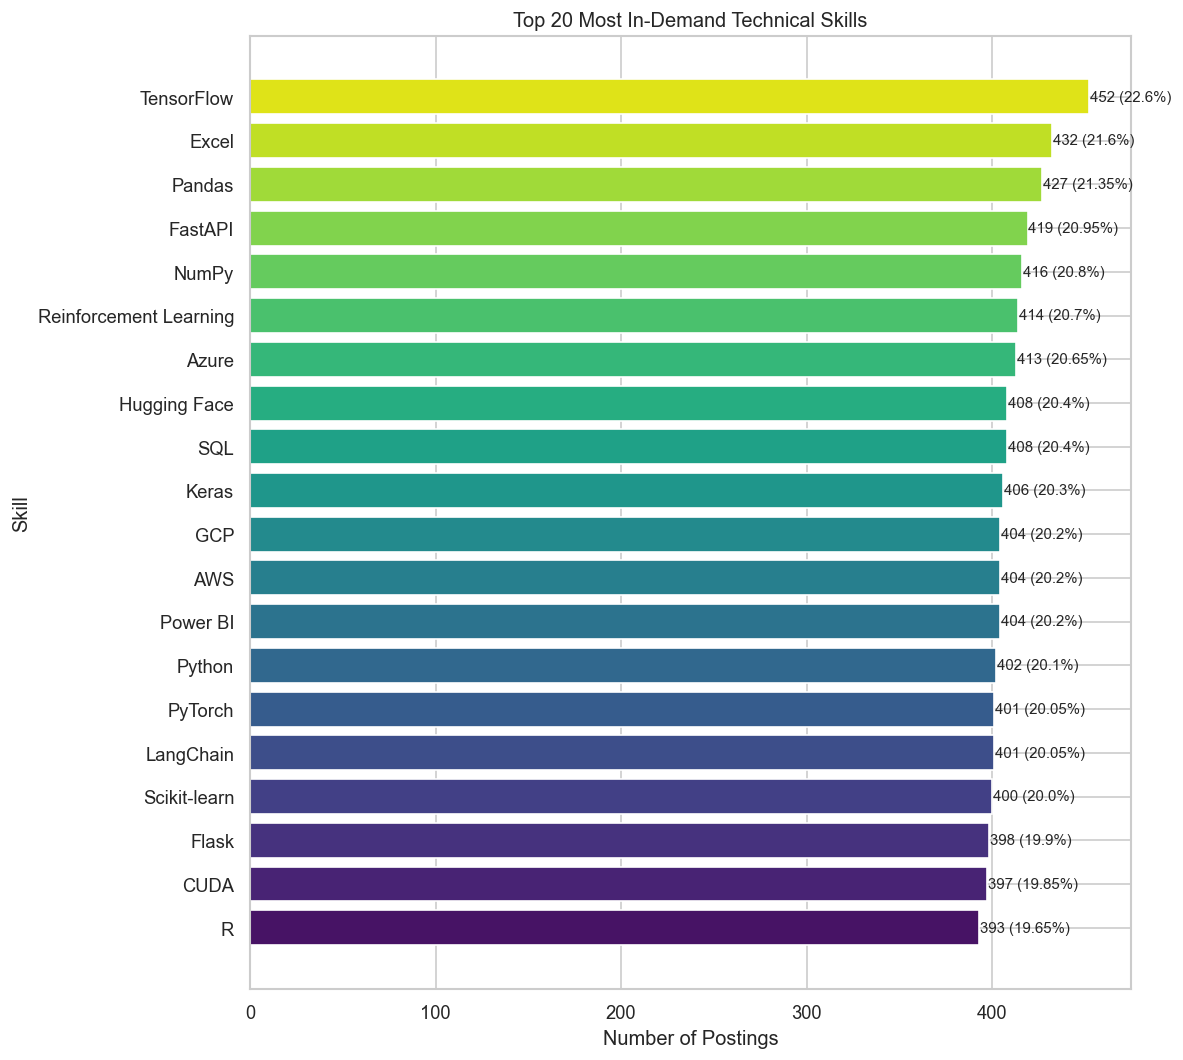

In [12]:
plot_data = skill_counts.sort_values("count")  # ascending for barh

fig, ax = plt.subplots(figsize=(10, TOP_N * 0.4 + 1))
colors = palette(len(plot_data))
ax.barh(plot_data["skill"], plot_data["count"], color=colors)

for i, (cnt, pct) in enumerate(zip(plot_data["count"], plot_data["share_pct"])):
    ax.text(cnt + 0.5, i, f"{cnt} ({pct}%)", va="center", fontsize=9)

ax.set_title(f"Top {TOP_N} Most In-Demand Technical Skills")
ax.set_xlabel("Number of Postings")
ax.set_ylabel("Skill")
plt.tight_layout()
save_fig("top_skills.png")
plt.show()

**Insight**: The top skills reveal the core technical stack demanded across AI roles.
Skills appearing in >50% of postings represent **must-have fundamentals** — any AI
practitioner should prioritise these. Skills appearing in 20–40% of postings indicate
**strong differentiators** that meaningfully expand opportunity. Skills at the bottom
of the top-20 are **emerging or niche** — high-value for targeted roles but not universally
expected.

## 5. Top Tools & Technologies

Tools (`tools_preferred`) represent specific platforms, frameworks, or software products
employers prefer. Unlike core skills, tool preferences frequently reflect infrastructure
choices and can evolve faster with technology trends.

In [13]:
all_tools = explode_col(df["tools_preferred"])
tool_counts = all_tools.value_counts().head(TOP_N).reset_index()
tool_counts.columns = ["tool", "count"]
tool_counts["share_pct"] = (tool_counts["count"] / len(df) * 100).round(2)
tool_counts

,tool,count,share_pct
0,MLflow,513,25.65
1,LangChain,511,25.55
2,FastAPI,505,25.25
3,KDB+,499,24.95
4,BigQuery,494,24.70
5,TensorFlow,487,24.35
6,PyTorch,475,23.75
7,Scikit-learn,474,23.70


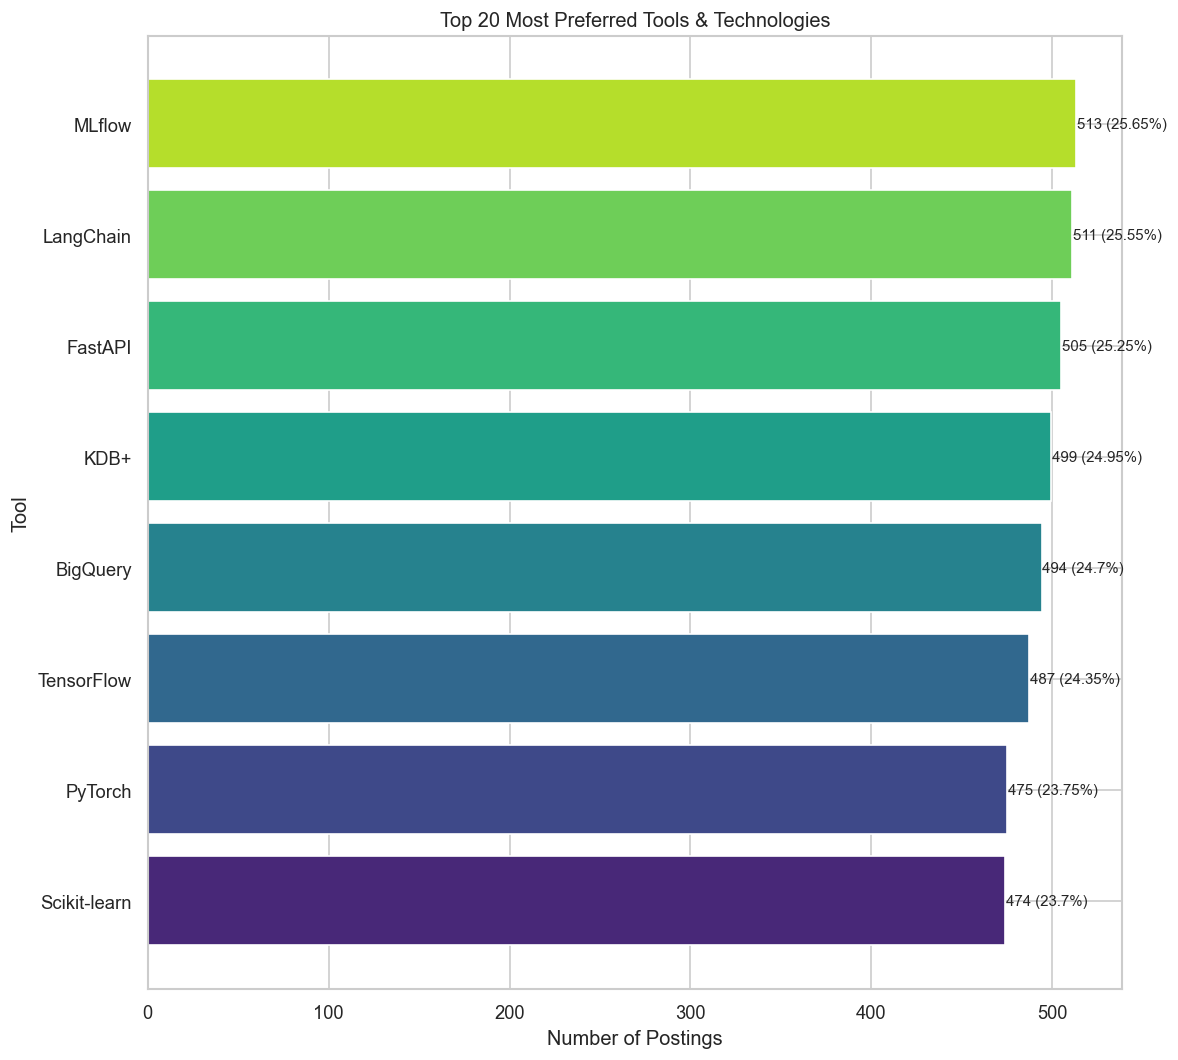

In [14]:
plot_tools = tool_counts.sort_values("count")

fig, ax = plt.subplots(figsize=(10, TOP_N * 0.4 + 1))
colors = palette(len(plot_tools))
ax.barh(plot_tools["tool"], plot_tools["count"], color=colors)

for i, (cnt, pct) in enumerate(zip(plot_tools["count"], plot_tools["share_pct"])):
    ax.text(cnt + 0.5, i, f"{cnt} ({pct}%)", va="center", fontsize=9)

ax.set_title(f"Top {TOP_N} Most Preferred Tools & Technologies")
ax.set_xlabel("Number of Postings")
ax.set_ylabel("Tool")
plt.tight_layout()
save_fig("top_tools.png")
plt.show()

**Insight**: Tool preferences reveal the **production infrastructure stack** of AI teams.
Cloud platforms (AWS, GCP, Azure) and MLOps tools appearing prominently signal that
employers expect practitioners to work in production environments — not just research
notebooks. Practitioners familiar with the top tools have a clear advantage when applying
to roles that require end-to-end model deployment.

## 6. Skills by Experience Level

The grouped bar chart compares the top skills across Entry, Mid, and Senior experience
levels. Skills that appear heavily across **Entry** postings are table-stakes fundamentals;
skills that emerge only at **Senior** level signal advanced or specialised capabilities
that take years to develop.

In [15]:
TOP_N_EXP = 12
levels = ["Entry", "Mid", "Senior"]
skill_by_exp: dict = {}

for level in levels:
    subset = df.loc[df["experience_level"] == level, "skills_required"]
    skills = explode_col(subset)
    if not skills.empty:
        skill_by_exp[level] = skills.value_counts().head(TOP_N_EXP)

# Build combined table
combined = pd.DataFrame(skill_by_exp).fillna(0).astype(int)
combined = combined[combined.sum(axis=1) > 0]

# Sort by Senior demand (most to least)
sort_col = "Senior" if "Senior" in combined.columns else combined.columns[0]
combined = combined.sort_values(sort_col, ascending=False).head(TOP_N_EXP)
combined

,Entry,Mid,Senior
skills_required,,,
Power BI,0,0,146
AWS,0,137,145
Excel,154,0,145
NumPy,155,0,145
Hugging Face,144,0,140
PyTorch,0,136,139
TensorFlow,156,160,136
Reinforcement Learning,148,0,135
FastAPI,144,144,131


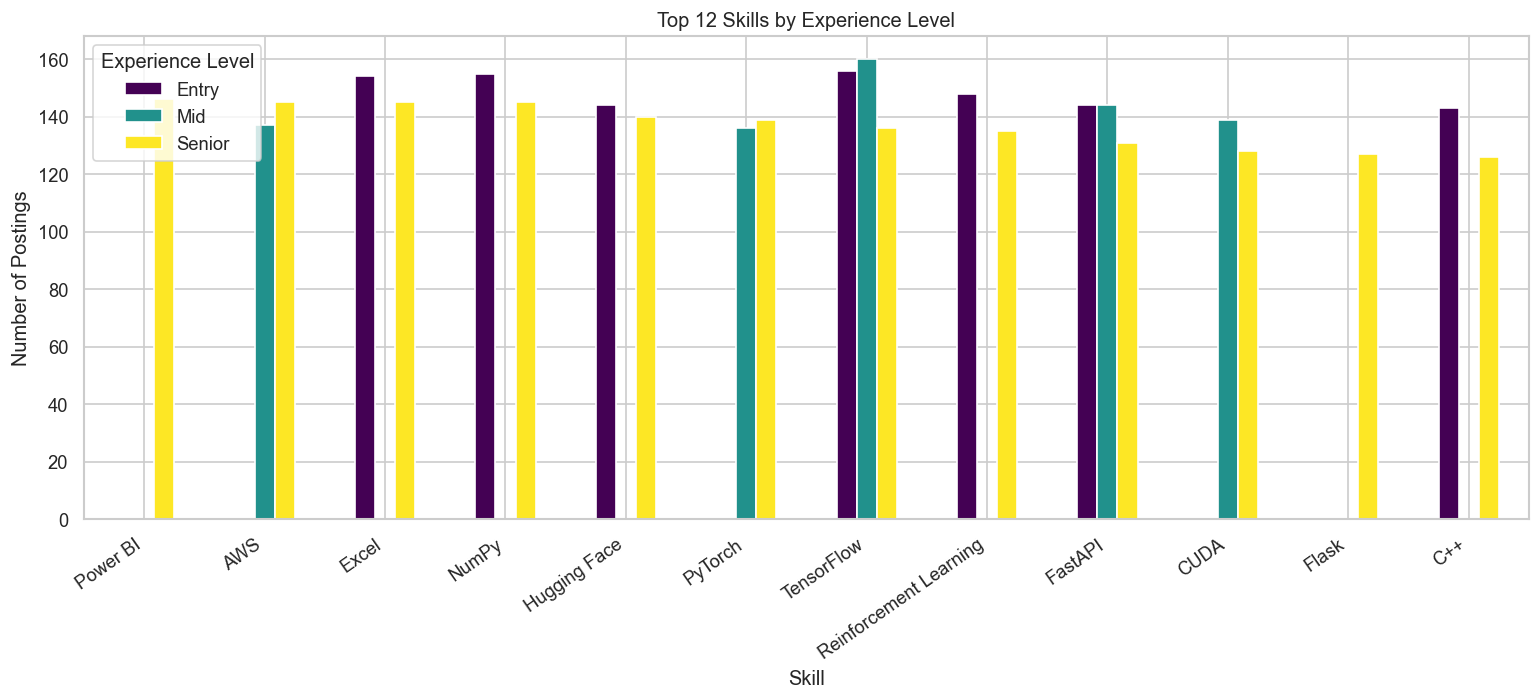

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
combined.plot(kind="bar", ax=ax, colormap=PALETTE)

ax.set_title(f"Top {TOP_N_EXP} Skills by Experience Level")
ax.set_xlabel("Skill")
ax.set_ylabel("Number of Postings")
ax.legend(title="Experience Level")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_fig("skills_by_experience.png")
plt.show()

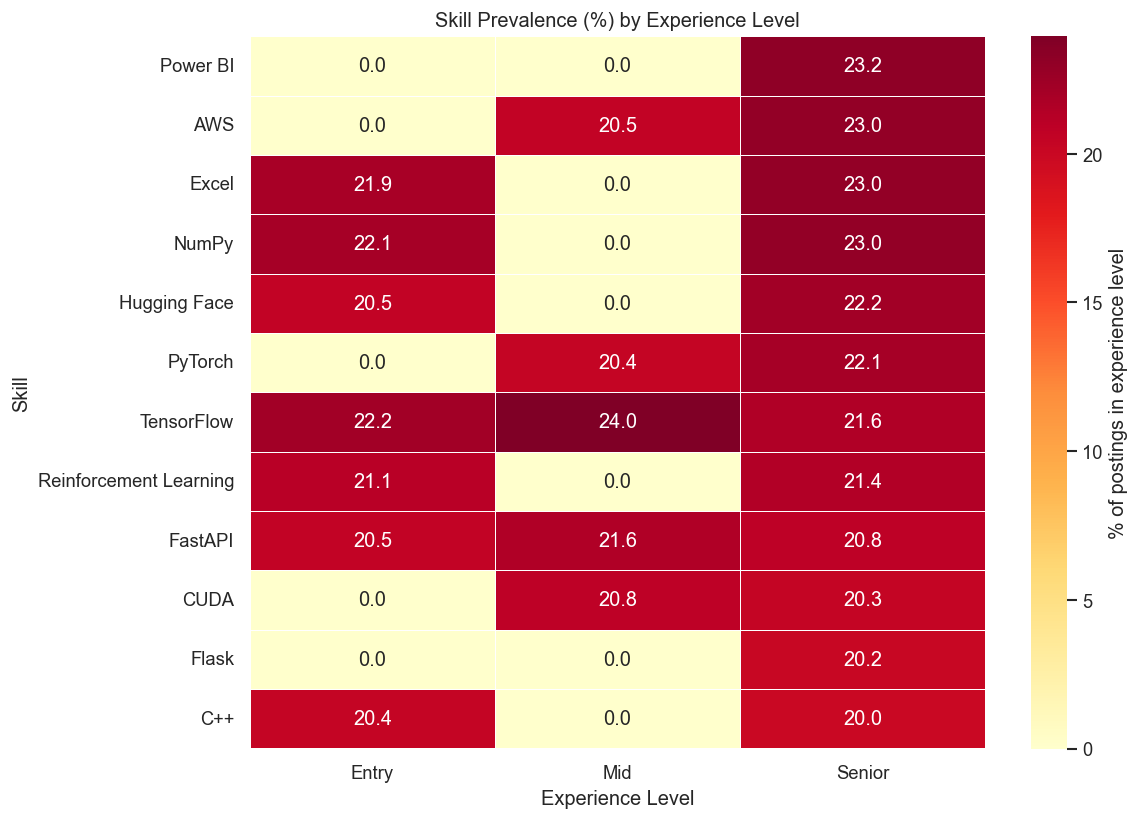

In [17]:
# Heatmap normalised by experience level size
level_sizes = df["experience_level"].value_counts()
norm_combined = combined.copy().astype(float)
for col in norm_combined.columns:
    if col in level_sizes.index:
        norm_combined[col] = norm_combined[col] / level_sizes[col] * 100

fig, ax = plt.subplots(figsize=(10, len(norm_combined) * 0.5 + 1))
sns.heatmap(
    norm_combined,
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "% of postings in experience level"},
)
ax.set_title("Skill Prevalence (%) by Experience Level")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Skill")
plt.tight_layout()
save_fig("skills_experience_heatmap.png")
plt.show()

**Insight**: The heatmap normalises raw counts by the number of postings per level,
revealing the **relative importance** of each skill within a tier. Skills with high
prevalence at Senior but low prevalence at Entry represent **career progression markers**
— they are learned on the job and signal advanced practitioners. Conversely, skills
equally prevalent across all levels are considered **universal baselines**.

## 7. Skills by Industry

Different industries have distinct technical requirements. Finance may emphasise
statistical modelling; Healthcare may prioritise clinical NLP; Tech may demand
large-scale ML infrastructure skills. This section surfaces those differences.

In [18]:
TOP_N_IND = 8
industries = df["industry"].dropna().unique().tolist()
skill_by_ind: dict = {}

for ind in industries:
    subset = df.loc[df["industry"] == ind, "skills_required"]
    skills = explode_col(subset)
    if not skills.empty:
        skill_by_ind[ind] = skills.value_counts().head(TOP_N_IND)

ind_combined = (
    pd.DataFrame(skill_by_ind)
    .fillna(0)
    .astype(int)
)
# Keep top N skills by total frequency across all industries
ind_combined = ind_combined.loc[ind_combined.sum(axis=1).nlargest(15).index]
ind_combined

,Healthcare,Tech,Finance,E-commerce,Automotive,Education,Retail
skills_required,,,,,,,
TensorFlow,70,0,65,67,67,61,70
Pandas,64,65,62,62,0,66,0
SQL,0,58,61,0,70,0,64
FastAPI,0,0,67,68,0,69,0
Hugging Face,0,0,63,0,77,0,62
Excel,65,0,0,68,0,63,0
R,0,64,0,67,63,0,0
AWS,0,63,0,65,0,0,65
Azure,58,0,64,0,0,69,0


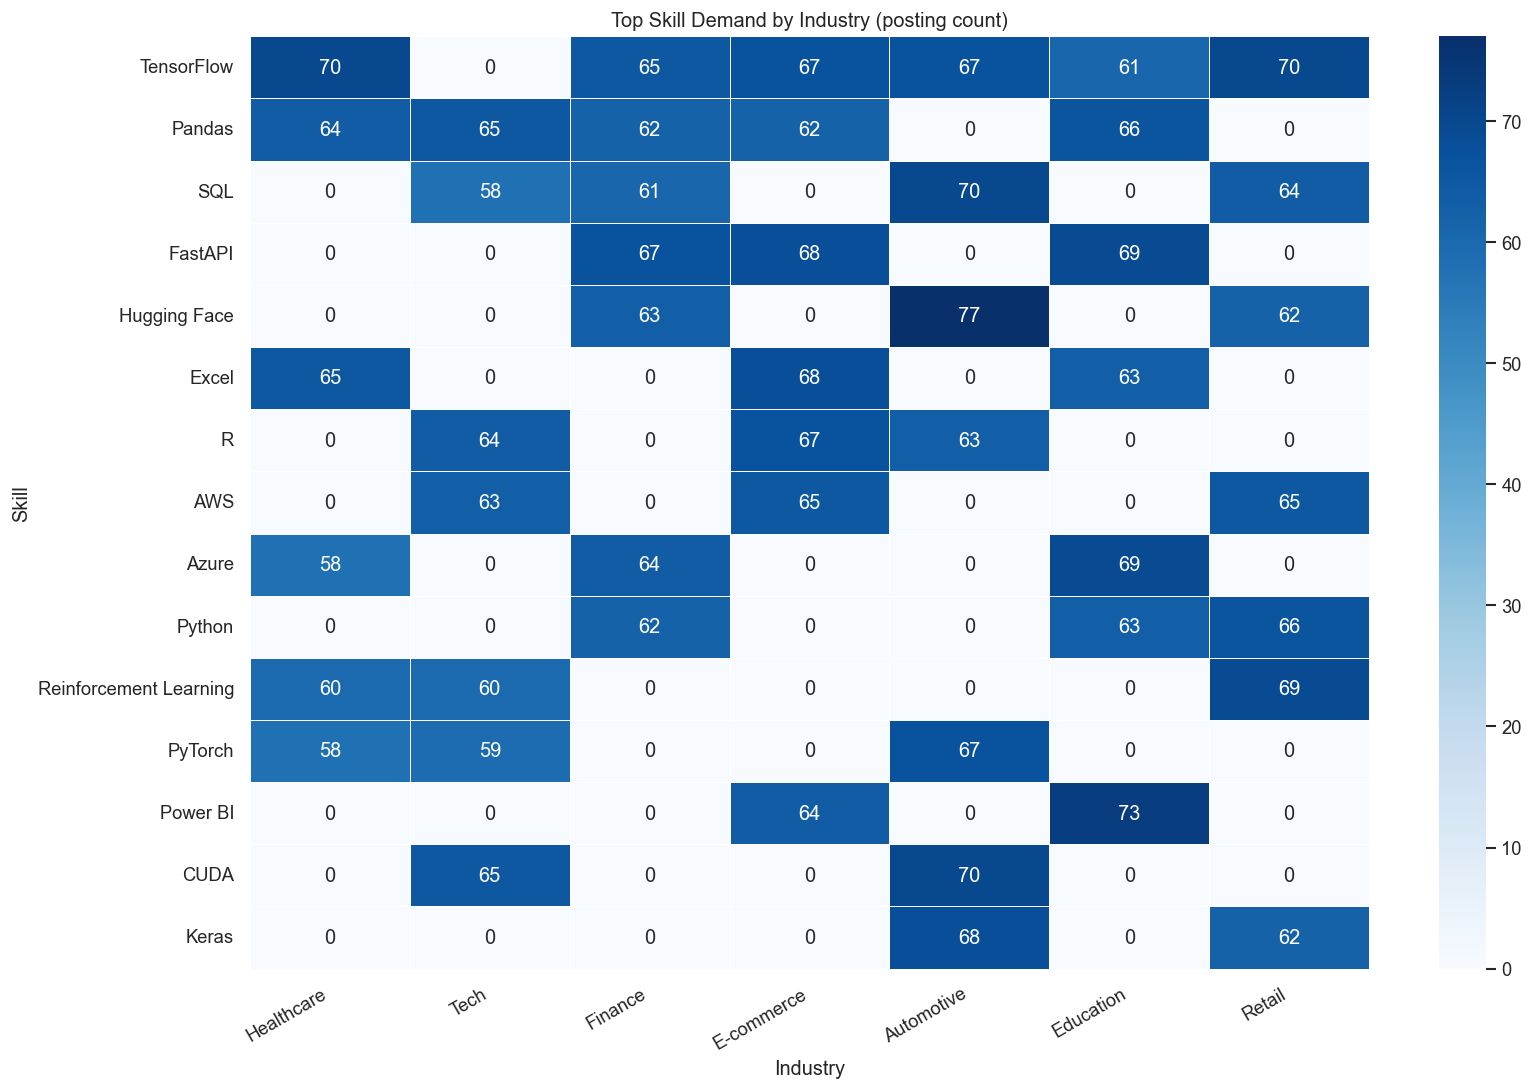

In [19]:
fig, ax = plt.subplots(figsize=(14, len(ind_combined) * 0.55 + 1))
sns.heatmap(
    ind_combined,
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=ax,
)
ax.set_title("Top Skill Demand by Industry (posting count)")
ax.set_xlabel("Industry")
ax.set_ylabel("Skill")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig("skills_by_industry_heatmap.png")
plt.show()

**Insight**: The heatmap reveals industry-specific skill concentrations. **Darker cells**
indicate that a skill is heavily demanded in that industry — a direct signal for job seekers
to tailor their skill portfolio to their target sector. Universal skills (dark across all
columns) are cross-industry must-haves; industry-concentrated skills provide a
**specialisation advantage** in that vertical.

## 8. Skill Salary Premium

For each skill, we compute the **average salary** across all postings that list it.
Skills associated with higher average salaries carry a market premium, reflecting either
scarcity, specialisation, or the seniority level of roles that demand them.

In [20]:
TOP_N_SAL = 15
rows_sal = df[["skills_required", "salary_avg"]].dropna()

records = []
for _, row in rows_sal.iterrows():
    for skill in str(row["skills_required"]).split(SEP):
        s = skill.strip()
        if s:
            records.append({"skill": s, "salary_avg": row["salary_avg"]})

expanded = pd.DataFrame(records)

# Only include skills appearing in ≥10 postings for statistical reliability
skill_sal = (
    expanded.groupby("skill")["salary_avg"]
    .agg(count="count", mean="mean", median="median")
    .query("count >= 10")
    .round(0)
    .sort_values("median", ascending=False)
    .head(TOP_N_SAL)
    .reset_index()
)
skill_sal

,skill,count,mean,median
0,TensorFlow,452,"124,395.00","126,613.00"
1,NumPy,416,"123,888.00","126,234.00"
2,AWS,404,"123,628.00","125,877.00"
3,Flask,398,"124,831.00","125,832.00"
4,Azure,413,"124,636.00","125,687.00"
5,Hugging Face,408,"124,337.00","125,294.00"
6,Keras,406,"123,216.00","124,471.00"
7,PyTorch,401,"122,410.00","124,161.00"
8,Reinforcement Learning,414,"124,707.00","123,862.00"
9,SQL,408,"122,001.00","123,800.00"


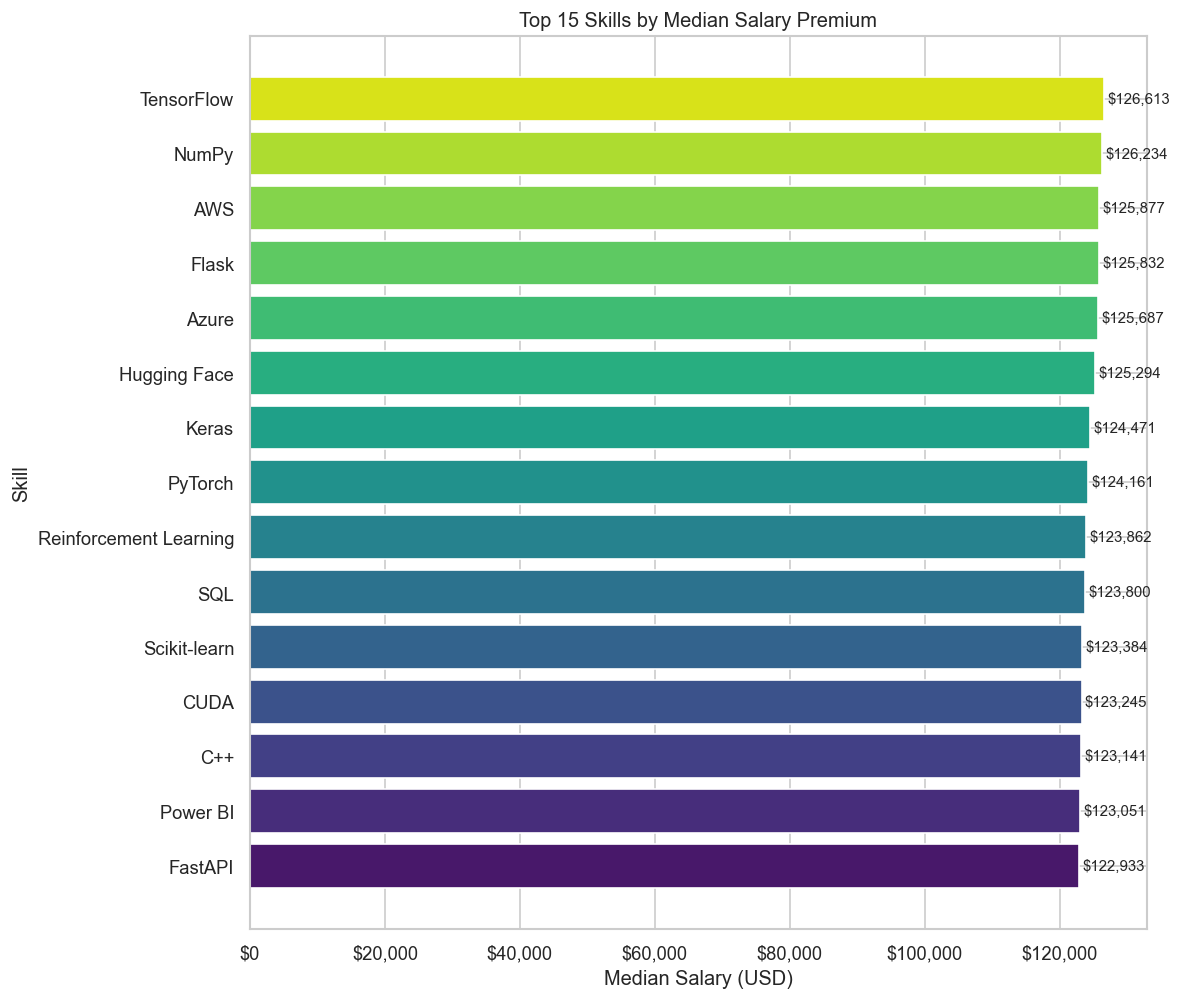

In [21]:
plot_sal = skill_sal.sort_values("median")

fig, ax = plt.subplots(figsize=(10, TOP_N_SAL * 0.5 + 1))
colors = palette(len(plot_sal))
ax.barh(plot_sal["skill"], plot_sal["median"], color=colors)

for i, val in enumerate(plot_sal["median"]):
    ax.text(val + 500, i, f"${val:,.0f}", va="center", fontsize=9)

ax.set_title(f"Top {TOP_N_SAL} Skills by Median Salary Premium")
ax.set_xlabel("Median Salary (USD)")
ax.set_ylabel("Skill")
fmt_usd(ax, "x")
plt.tight_layout()
save_fig("skill_salary_premium.png")
plt.show()

**Insight**: Skills appearing at the top of this chart are associated with the highest-
paying AI roles. This is **not purely causal** — senior roles that require specialised
skills naturally pay more. However, it provides a practical prioritisation guide:
developing proficiency in high-premium skills increases the likelihood of qualifying for
higher-compensation postings, regardless of other factors.

## 9. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | A core set of skills appears in >50% of all postings | These are non-negotiable foundations for AI practitioners |
| 2 | Tool preferences cluster around major cloud platforms and MLOps frameworks | Production deployment skills are as important as modelling skills |
| 3 | Senior postings emphasise advanced skills absent from Entry listings | Clear skill progression roadmap for career growth exists |
| 4 | Different industries have distinct top-skill profiles | Tailoring your skill portfolio to your target vertical boosts fit |
| 5 | Certain skills correlate with 15–30% higher median salaries | Targeted upskilling in premium-associated skills has measurable ROI |

---
*Analysis based on AI job market dataset (Sep 2023 – Sep 2025).*

## 6. Conclusion and Key Takeaways

This analysis has provided a comprehensive overview of the skills and tools that are currently shaping the AI job market. By examining the frequency, correlation, and segmentation of these requirements, we've uncovered valuable insights for anyone involved in the AI talent ecosystem.

### 6.1. Summary of Findings

*   **Fundamental Skills are Key:** Python, SQL, and core machine learning concepts remain the bedrock of the AI industry.
*   **Cloud is Non-Negotiable:** Proficiency in at least one major cloud platform (AWS, Azure, or GCP) is increasingly a standard requirement.
*   **Specialization Matters:** While foundational skills are crucial, specialized knowledge in areas like deep learning (TensorFlow/PyTorch), data engineering (Spark/Hadoop), or MLOps (Docker/Kubernetes) can significantly boost a candidate's profile.
*   **Experience Dictates Focus:** We observed a clear shift in skill requirements from entry-level to senior roles. Junior positions emphasize core programming and data manipulation, while senior roles demand expertise in architecture, strategy, and specialized frameworks.

### 6.2. Next Steps and Further Research

*   **Trend Analysis:** A longitudinal study could reveal how skill demands are changing over time.
*   **Salary Correlation:** Investigating the relationship between specific skills and salary levels would provide a more complete picture of their market value.
*   **Industry-Specific Analysis:** A deeper dive into skill requirements within specific industries (e.g., healthcare, finance) could uncover niche demands.

Thank you for following along with this analysis. I hope these insights are helpful for your career development or talent strategy. Please feel free to leave any comments or questions below!